# Import Environment variables

In [1]:
%run /home/jupyter/repos/Multi-trait-GWAS-in-admixed-populations/notebooks/Setting_Env_Variables.ipynb

Found bucket: id=rw-migration-aou-rw-f7a4d148, bucketName=rw-migration-aou-rw-f7a4d148
-> Assigned migration variables (ID: rw-migration-aou-rw-f7a4d148)
Found bucket: id=temporary-workspace-bucket, bucketName=temporary-workspace-bucket-wb-perky-cabbage-8342
Found bucket: id=workspace-bucket, bucketName=workspace-bucket-wb-perky-cabbage-8342
✅ Successfully identified latest dataset: wb-silky-artichoke-2408.C2024Q3R9

Variables extracted:
GOOGLE_CLOUD_PROJECT: wb-perky-cabbage-8342
WORKSPACE_BUCKET: gs://workspace-bucket-wb-perky-cabbage-8342
WORKSPACE_TEMP_BUCKET: gs://temporary-workspace-bucket-wb-perky-cabbage-8342
WORKSPACE_CDR: wb-silky-artichoke-2408.C2024Q3R9
bucket_aou_tutorial: NOT FOUND
bucket_id_aou_tutorial: NOT FOUND
bucket_migrated: gs://rw-migration-aou-rw-f7a4d148
bucket_id_migrated: rw-migration-aou-rw-f7a4d148

✅ Saved to /home/jupyter/.bashrc
C2024Q3R9 BQ_DATASET
Multi-trait-GWAS-in-admixed-populations GIT_REPO
dataset_test2 BQ_DATASET
prep_C2024Q3R9 BQ_DATASET
rw-mig

In [2]:
%run /home/jupyter/repos/Multi-trait-GWAS-in-admixed-populations/notebooks/Setting_Env_Variables_p2.ipynb

WORKSPACE_CDR = wb-silky-artichoke-2408.C2024Q3R9
WORKSPACE_BUCKET = gs://workspace-bucket-wb-perky-cabbage-8342
GOOGLE_PROJECT = wb-perky-cabbage-8342
Done! 10 variables saved to: /home/jupyter/repos/Multi-trait-GWAS-in-admixed-populations/notebooks/Setting_Env_Variables_p2.R
Done! 10 variables saved to: /home/jupyter/repos/Multi-trait-GWAS-in-admixed-populations/notebooks/Setting_Env_Variables.sas


# Import library

In [3]:
%load_ext autoreload
%autoreload 2
    
import os
import subprocess
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

# Importation des données issues du notebook `54_Breast_Cancer_WITHIN_5Y_DataSelectionAndFiltering`

In [4]:
# get the bucket name
my_bucket = os.getenv('WORKSPACE_BUCKET')

name_of_file_in_bucket = "df_bc_ko_at_inclusion_223k_nb_BC_WITHIN_5Y_GeneticAncestry_biopsy_FamilyHistory_LastSelection.tsv"

df = pd.read_csv(my_bucket +'/Data/'+ name_of_file_in_bucket, sep=',', low_memory=False)
df

,person_id,gender,date_of_birth,ethnicity,self_reported_category,inclusion_date,first_breast_cancer_date,delay_days,delay_years,time_category,...,Sibling,days_inclusion_to_first_survey,days_inclusion_to_last_survey,days_has_bc_to_first_survey,days_has_bc_to_last_survey,statut_parente,age_category,race_us_bcsc,race_us_bcsc_detail,breast_cancer_family_history_first_degree
0,1700611,Female,1949-06-15,What Race Ethnicity: Race Ethnicity None Of These,None of these,2019-09-17,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,Indépendant (Restant),72,2,afr_rye,0
1,1356439,Female,1949-06-15,What Race Ethnicity: Race Ethnicity None Of These,None of these,2019-03-04,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,Indépendant (Restant),67,3,eas_rye/sas_rye,0
2,3451057,Female,1951-06-15,What Race Ethnicity: Race Ethnicity None Of These,None of these,2023-01-18,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,Indépendant (Restant),72,3,eas_rye/sas_rye,0
3,1559161,Female,1951-06-15,What Race Ethnicity: Race Ethnicity None Of These,None of these,2019-03-11,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,Indépendant (Restant),67,8,amr_rye/mid_rye,0
4,1468526,Female,1956-06-15,What Race Ethnicity: Race Ethnicity None Of These,None of these,2019-10-07,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,Indépendant (Restant),62,1,eur_rye,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124896,4386725,Female,1982-06-15,Not Hispanic or Latino,White,2023-05-11,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,Indépendant (Restant),42,1,eur_rye,0
124897,2743914,Female,1982-06-15,Not Hispanic or Latino,White,2022-08-08,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,Indépendant (Restant),42,1,eur_rye,0
124898,1475516,Female,1982-06-15,Not Hispanic or Latino,White,2022-07-06,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,Indépendant (Restant),42,1,eur_rye,0
124899,9915233,Female,1982-06-15,Not Hispanic or Latino,White,2022-09-14,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,Indépendant (Restant),42,1,eur_rye,0


In [5]:
df.drop(columns=['gender','date_of_birth','ethnicity','self_reported_category','time_category','delay_years',
                 'first_any_biopsy_date','days_inclusion_to_biopsy', 'days_biopsy_to_cancer',
                 'first_survey_date', 'last_survey_date','days_last_survey_to_first_survey', 'days_inclusion_to_first_survey',
                 'days_inclusion_to_last_survey', 'days_has_bc_to_first_survey','days_has_bc_to_last_survey',
                 'date_1_of_biopsy_19081_19086', 'date_2_of_biopsy_19081_19086', 'date_3_of_biopsy_19081_19086',
                 'has_biopsy_19081_19086',
                 'date_1_of_biopsy_19100_19103', 'date_2_of_biopsy_19100_19103', 'date_3_of_biopsy_19100_19103',
                 'has_biopsy_19100_19103',
                 'date_1_of_biopsy_19120_19125_19126', 'date_2_of_biopsy_19120_19125_19126', 'date_3_of_biopsy_19120_19125_19126',
                 'has_biopsy_19120_19125_19126',
                 'Daughter', 'Mother', 'Sibling',
                 'statut_parente'], inplace=True)

In [6]:
df.columns

Index(['person_id', 'inclusion_date', 'first_breast_cancer_date', 'delay_days',
       'age_at_inclusion', 'has_bc', 'eur_rye', 'eas_rye', 'amr_rye',
       'afr_rye', 'sas_rye', 'mid_rye', 'dominant_origin', 'ancestry_80',
       'biopsy_result', 'age_category', 'race_us_bcsc', 'race_us_bcsc_detail',
       'breast_cancer_family_history_first_degree'],
      dtype='object')

# Calcul du score BCSC

## Script appliquant l'équation de régression logistique du modèle BCSC V2

In [7]:
import numpy as np
import pandas as pd


def calculate_bcsc_v2_risk_5years(row):
    """Calcule le risque absolu à 5 ans de cancer du sein invasif (Modèle BCSC v2)

    sans donnée de densité (densité imputée/neutre).
    """
    age = row["age_at_inclusion"]
    race = row["race_us_bcsc"]  # 1: White, 2: Black, 3: Asian, 8: Other/Mixed
    fam_hist = row[
        "breast_cancer_family_history_first_degree"
    ]  # 0: Non, 1: Oui (1 relative), 2: Oui (>=2 relatives)
    biopsy = row["biopsy_result"]  # 0: Non, 1: Oui (biopsie bénigne)

    # 1. Odds Ratios (Log-Odds) du modèle BCSC v2 (Tice et al. 2015)
    # Relative Risk (RR) par rapport à la catégorie de référence

    # Antecedents familiaux
    beta_fam = {0: 0.0, 1: 0.47, 2: 0.88}.get(fam_hist, 0.0)

    # Antécédent de biopsie bénigne
    beta_biopsy = 0.36 if biopsy == 1 else 0.0

    # Ethnicité (Ajustement du risque de base relative)
    beta_race = {
        1: 0.0,  # White (Référence)
        2: -0.12,  # Black
        3: -0.22,  # Asian
        8: -0.05,  # Other / Mixed
    }.get(race, 0.0)

    # Densité inconnue (Poids neutre / Risque relatif moyen = 1.0 -> beta = 0.0)
    beta_density = 0.0

    # 2. Somme des effets relatifs (Log Relative Risk)
    log_rr = beta_fam + beta_biopsy + beta_race + beta_density
    rr = np.exp(log_rr)

    # 3. Taux d'incidence de base (Baseline Hazard à 5 ans selon l'âge)
    # Issu des tables d'incidence de référence BCSC / SEER (Tice et al.)
    if 40 <= age < 45:
        base_rate_5yr = 0.0051
    elif 45 <= age < 50:
        base_rate_5yr = 0.0084
    elif 50 <= age < 55:
        base_rate_5yr = 0.0118
    elif 55 <= age < 60:
        base_rate_5yr = 0.0142
    elif 60 <= age < 65:
        base_rate_5yr = 0.0163
    elif 65 <= age < 70:
        base_rate_5yr = 0.0178
    elif 70 <= age < 75:
        base_rate_5yr = 0.0185
    else:
        base_rate_5yr = 0.0100  # Hors bornes

    # 4. Calcul du risque absolu à 5 ans
    # Risk = 1 - exp(- Baseline_Hazard * RR)
    risk_5yr = 1.0 - np.exp(-base_rate_5yr * rr)

    return risk_5yr

## Application du modèle BCSC

In [8]:
# Application sur ton DataFrame
df["score_bcscRisk"] = (df.apply(calculate_bcsc_v2_risk_5years, axis=1))

<Axes: ylabel='Frequency'>

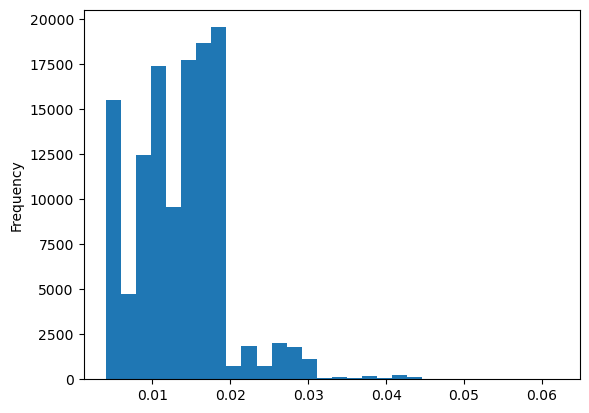

In [9]:
df["score_bcscRisk"].plot.hist(bins=30)

# Evaluation de performance du modèle bcscRisk

## Evaluation globale

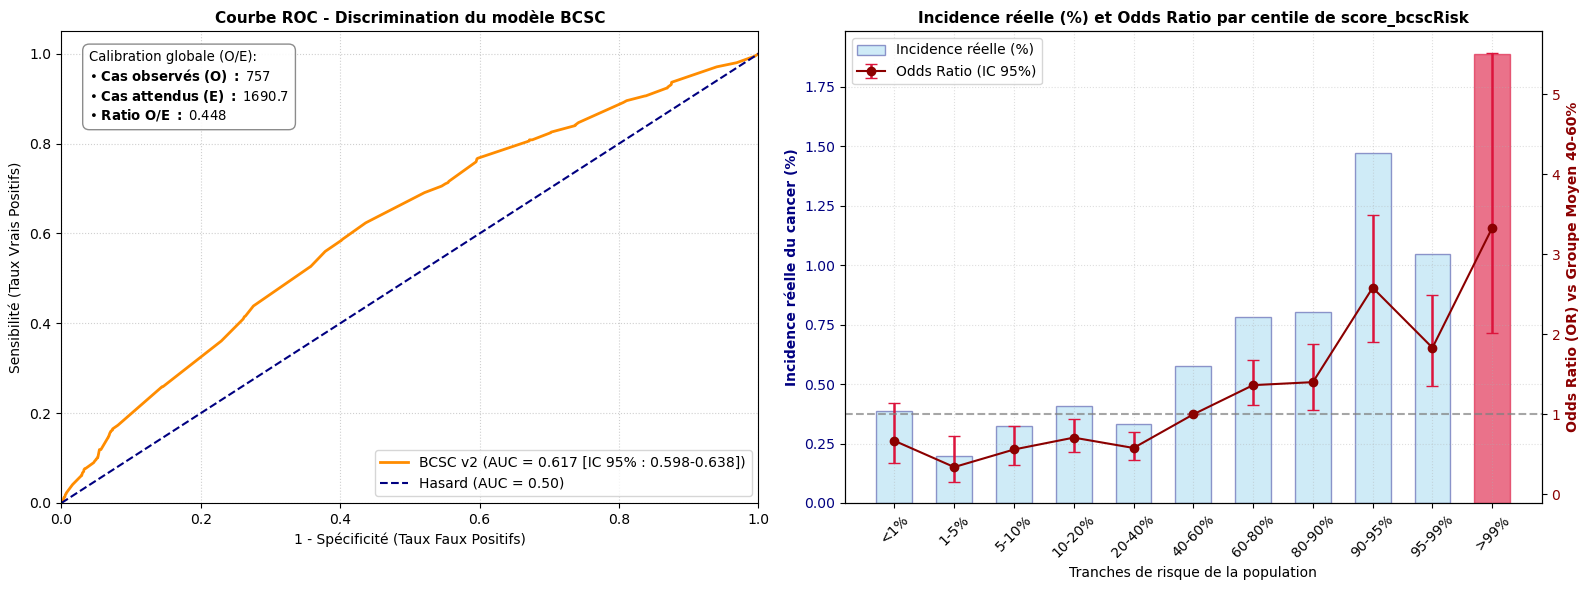

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import auc, roc_curve

# 1. Nettoyage des données
df_eval = df.dropna(subset=["has_bc", "score_bcscRisk"]).copy()

y_true = df_eval["has_bc"]
y_scores = df_eval["score_bcscRisk"]

# -------------------------------------------------------------------------
# A. Calcul de l'AUC-ROC et IC 95% (Bootstrap)
# -------------------------------------------------------------------------
fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)


def bootstrap_auc(y_true, y_scores, n_bootstraps=1000, rng_seed=42):
    bootstrapped_scores = []
    rng = np.random.RandomState(rng_seed)
    y_true_arr = np.array(y_true)
    y_scores_arr = np.array(y_scores)

    for _ in range(n_bootstraps):
        indices = rng.randint(0, len(y_scores_arr), len(y_scores_arr))
        if len(np.unique(y_true_arr[indices])) < 2:
            continue
        score = auc(*roc_curve(y_true_arr[indices], y_scores_arr[indices])[:2])
        bootstrapped_scores.append(score)

    sorted_scores = np.sort(bootstrapped_scores)
    return sorted_scores[int(0.025 * len(sorted_scores))], sorted_scores[
        int(0.975 * len(sorted_scores))
    ]


ci_lower, ci_upper = bootstrap_auc(y_true, y_scores)

# -------------------------------------------------------------------------
# B. Ratio O/E (Observed / Expected)
# -------------------------------------------------------------------------
observed_cases = int(y_true.sum())
expected_cases = float(y_scores.sum())
oe_ratio = observed_cases / expected_cases

# -------------------------------------------------------------------------
# C. Calcul des quantiles, de l'incidence et des Odds Ratios
# -------------------------------------------------------------------------
quantiles = [
    0.0,
    0.01,
    0.05,
    0.10,
    0.20,
    0.40,
    0.60,
    0.80,
    0.90,
    0.95,
    0.99,
    1.0,
]
labels = [
    "<1%",
    "1-5%",
    "5-10%",
    "10-20%",
    "20-40%",
    "40-60%",
    "60-80%",
    "80-90%",
    "90-95%",
    "95-99%",
    ">99%",
]

df_eval["risk_group"] = pd.cut(
    df_eval["score_bcscRisk"],
    bins=df_eval["score_bcscRisk"].quantile(quantiles),
    labels=labels,
    include_lowest=True,
)

# 1. Calcul de l'incidence réelle (%)
incidence = df_eval.groupby("risk_group", observed=False)["has_bc"].agg(
    ["mean", "count"]
)
incidence["pct"] = incidence["mean"] * 100
incidence = incidence.reindex(labels)

# 2. Calcul des Odds Ratios par régression logistique (référence = '40-60%')
dummies = pd.get_dummies(df_eval["risk_group"], drop_first=False)
ref_col = "40-60%"
X = dummies.drop(columns=[ref_col]).astype(int)
X = sm.add_constant(X)

logit_mod = sm.Logit(y_true, X).fit(disp=False)
conf = logit_mod.conf_int()

or_df = pd.DataFrame(
    {
        "OR": np.exp(logit_mod.params),
        "lower": np.exp(conf[0]),
        "upper": np.exp(conf[1]),
    }
)
or_df.loc["const"] = [1.0, 1.0, 1.0]
or_df.index = [c if c != "const" else ref_col for c in or_df.index]
or_df = or_df.reindex(labels)

# -------------------------------------------------------------------------
# D. Affichage des deux sous-graphiques côte à côte
# -------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Graphique 1 : ROC ---
axes[0].plot(
    fpr,
    tpr,
    color="darkorange",
    lw=2,
    label=f"BCSC v2 (AUC = {roc_auc:.3f} [IC 95% : {ci_lower:.3f}-{ci_upper:.3f}])",
)
axes[0].plot(
    [0, 1],
    [0, 1],
    color="navy",
    lw=1.5,
    linestyle="--",
    label="Hasard (AUC = 0.50)",
)
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel("1 - Spécificité (Taux Faux Positifs)", fontsize=10)
axes[0].set_ylabel("Sensibilité (Taux Vrais Positifs)", fontsize=10)
axes[0].set_title(
    "Courbe ROC - Discrimination du modèle BCSC", fontsize=11, fontweight="bold"
)
axes[0].legend(loc="lower right")
axes[0].grid(True, linestyle=":", alpha=0.6)

# AJOUT DU CARTOUCHE DE CALIBRATION DANS LE SUBPLOT ROC
text_str = (
    r"Calibration globale (O/E):"
    "\n"
    rf"• $\mathbf{{Cas\ observés\ (O)\ :}}$ {observed_cases}"
    "\n"
    rf"• $\mathbf{{Cas\ attendus\ (E)\ :}}$ {expected_cases:.1f}"
    "\n"
    rf"• $\mathbf{{Ratio\ O/E\ :}}$ {oe_ratio:.3f}"
)

axes[0].text(
    0.04,
    0.96,
    text_str,
    transform=axes[0].transAxes,
    fontsize=9.5,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray", alpha=0.9),
)

# --- Graphique 2 : Combiné (Incidence % [Barres] + OR [Ligne/Points]) ---
x_pos = np.arange(len(labels))

# Axe Y principal (Gauche) : Incidence en %
bars = axes[1].bar(
    x_pos,
    incidence["pct"],
    alpha=0.4,
    color="skyblue",
    edgecolor="navy",
    width=0.6,
    label="Incidence réelle (%)",
)
# Mise en valeur du dernier centile (>99%)
bars[-1].set_color("crimson")
bars[-1].set_alpha(0.6)

axes[1].set_xlabel("Tranches de risque de la population", fontsize=10)
axes[1].set_ylabel(
    "Incidence réelle du cancer (%)",
    fontsize=10,
    color="navy",
    fontweight="bold",
)
axes[1].tick_params(axis="y", labelcolor="navy")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(labels, rotation=45)
axes[1].grid(True, linestyle=":", alpha=0.4)

# Axe Y secondaire (Droite) : Odds Ratios
ax2 = axes[1].twinx()
line_or = ax2.errorbar(
    x_pos,
    or_df["OR"],
    yerr=[or_df["OR"] - or_df["lower"], or_df["upper"] - or_df["OR"]],
    fmt="o-",
    color="darkred",
    ecolor="crimson",
    elinewidth=1.8,
    capsize=4,
    markersize=6,
    label="Odds Ratio (IC 95%)",
)
ax2.axhline(1.0, color="gray", linestyle="--", alpha=0.7)
ax2.set_ylabel(
    "Odds Ratio (OR) vs Groupe Moyen 40-60%",
    fontsize=10,
    color="darkred",
    fontweight="bold",
)
ax2.tick_params(axis="y", labelcolor="darkred")

# Légende combinée pour le graphique 2
lines_1, labels_1 = axes[1].get_legend_handles_labels()
axes[1].legend(
    lines_1 + [line_or],
    labels_1 + ["Odds Ratio (IC 95%)"],
    loc="upper left",
    frameon=True,
)

axes[1].set_title(
    "Incidence réelle (%) et Odds Ratio par centile de score_bcscRisk",
    fontsize=11,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

1. **AUC-ROC (Area Under the ROC Curve) :** Évalue la capacité globale de discrimination.
    * **Si l'AUC est comprise entre $0,60$ et $0,68$ :** C'est la performance clinique standard attendue pour les modèles épidémiologiques de première génération (BCSC, Gail, Tyrer-Cuzick sans génétique ni densité). Dans l'article d'Elie Rassy et al., les scores cliniques seuls se situent exactement dans cette zone avant l'ajout du score de risque polygénique (PRS).
3. **Courbe ROC :** Visualisation du compromis entre sensibilité et spécificité.
4. **Courbe de Calibration :** Compare le risque moyen prédit au taux de cancer réel par décile de risque.
5. **Ratio O/E (Observed / Expected) :** Évalue la sur-estimation ou sous-estimation globale du modèle.
    * Interprétation du Ratio O/E :
      * $\text{O/E} \approx 1,0$ : Le modèle est parfaitement calibré sur la cohorte.
      * $\text{O/E} < 1,0$ : Le modèle sur-estime le risque réel dans All of Us.
      * $\text{O/E} > 1,0$ : Le modèle sous-estime le risque.

## Evaluation selon l'ethnie


==================== Analyse pour : afr_rye ====================


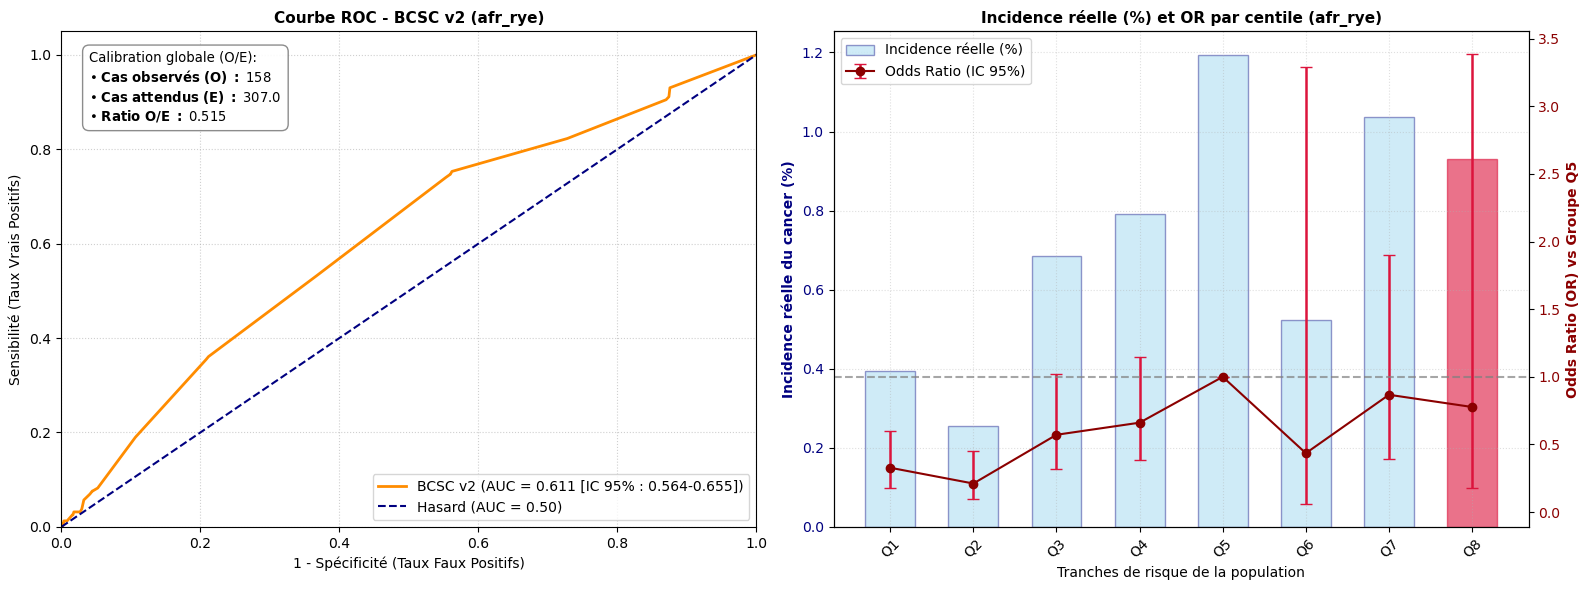


==================== Analyse pour : eas_rye/sas_rye ====================


/opt/conda/envs/jupyter/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/conda/envs/jupyter/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


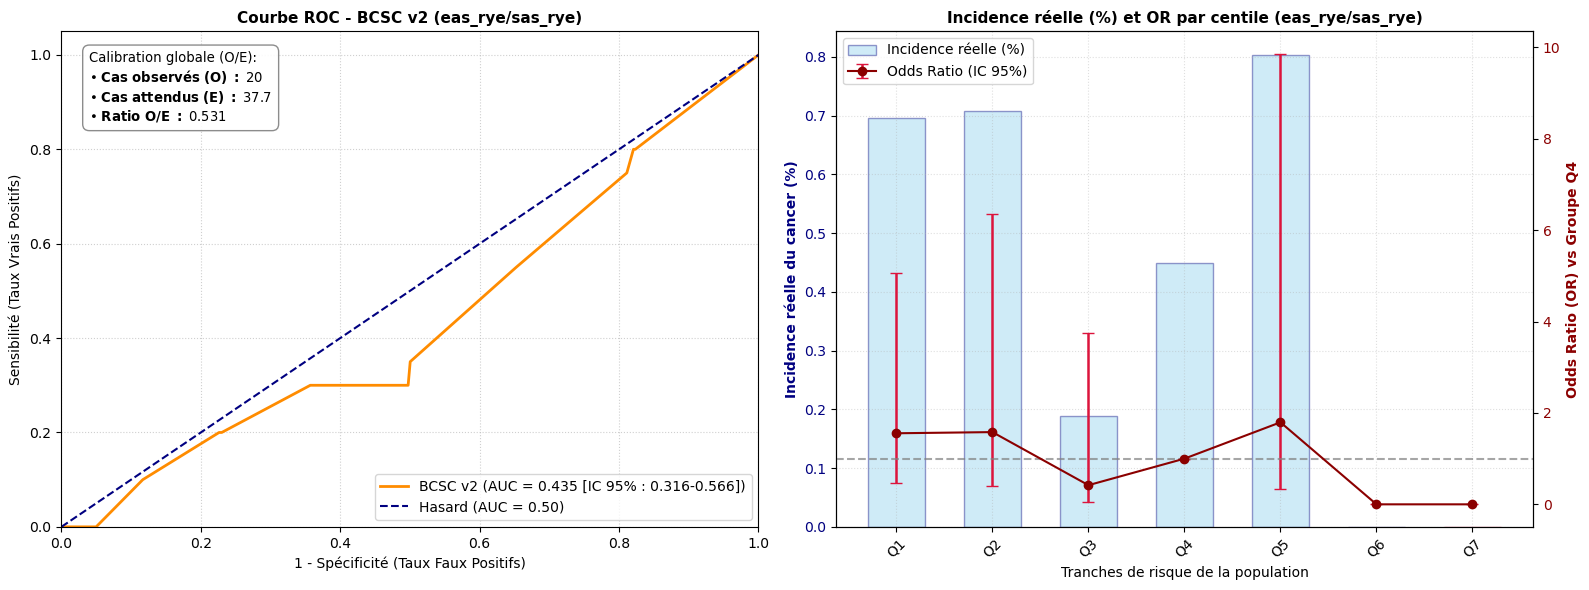


==================== Analyse pour : amr_rye/mid_rye ====================


/opt/conda/envs/jupyter/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


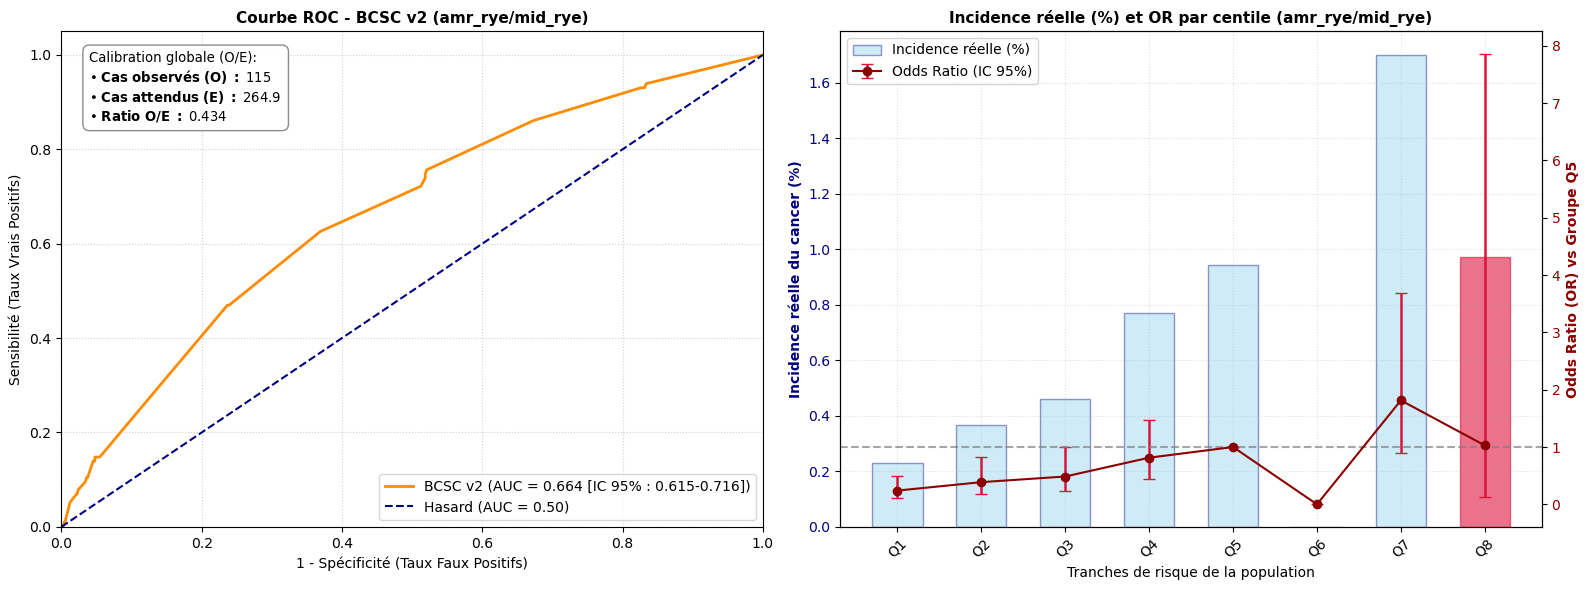


==================== Analyse pour : eur_rye ====================


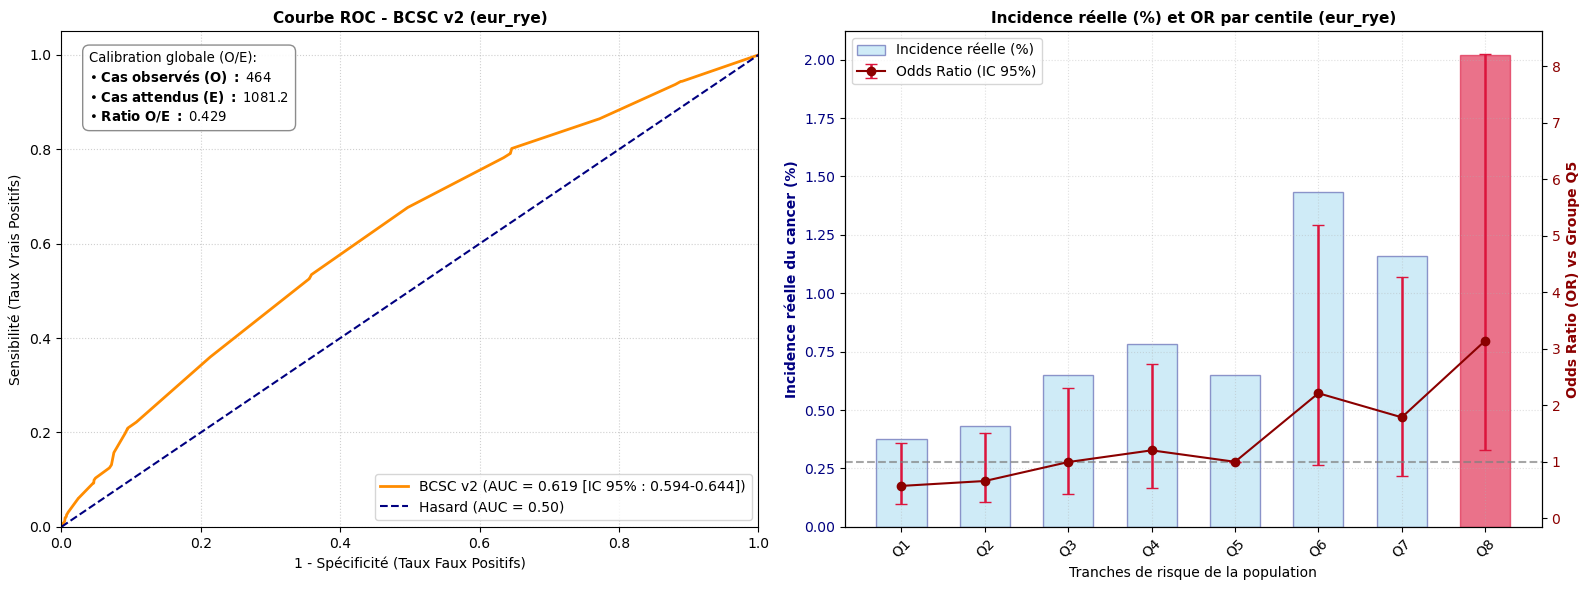

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import auc, roc_curve


# 1. Définition de la fonction Bootstrap hors de la boucle
def bootstrap_auc(y_true, y_scores, n_bootstraps=1000, rng_seed=42):
    bootstrapped_scores = []
    rng = np.random.RandomState(rng_seed)
    y_true_arr = np.array(y_true)
    y_scores_arr = np.array(y_scores)

    for _ in range(n_bootstraps):
        indices = rng.randint(0, len(y_scores_arr), len(y_scores_arr))
        if len(np.unique(y_true_arr[indices])) < 2:
            continue
        score = auc(*roc_curve(y_true_arr[indices], y_scores_arr[indices])[:2])
        bootstrapped_scores.append(score)

    if len(bootstrapped_scores) == 0:
        return np.nan, np.nan

    sorted_scores = np.sort(bootstrapped_scores)
    return sorted_scores[int(0.025 * len(sorted_scores))], sorted_scores[
        int(0.975 * len(sorted_scores))
    ]


# 2. Liste des origines/ethnies uniques
ethnies = list(df["race_us_bcsc_detail"].dropna().unique())

for i in ethnies:
    print(f"\n==================== Analyse pour : {i} ====================")

    # Filtrage et copie propre
    df_sub = df[df["race_us_bcsc_detail"] == i]
    df_eval = df_sub.dropna(subset=["has_bc", "score_bcscRisk"]).copy()

    y_true = df_eval["has_bc"]
    y_scores = df_eval["score_bcscRisk"]

    # Sécurité : Vérifier qu'il y a assez de données et au moins 1 cas + 1 contrôle
    if len(df_eval) < 10 or len(np.unique(y_true)) < 2:
        print(
            f"[SKIP] Pas assez d'échantillons ou de cas de cancer pour"
            f" l'ethnie : {i}"
        )
        continue

    # A. Calcul de l'AUC-ROC et IC 95%
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    ci_lower, ci_upper = bootstrap_auc(y_true, y_scores)

    # B. Ratio O/E
    observed_cases = int(y_true.sum())
    expected_cases = float(y_scores.sum())
    oe_ratio = (
        observed_cases / expected_cases if expected_cases > 0 else np.nan
    )

    # C. Calcul des quantiles dynamiques et sécurisés
    quantiles = [
        0.0,
        0.01,
        0.05,
        0.10,
        0.20,
        0.40,
        0.60,
        0.80,
        0.90,
        0.95,
        0.99,
        1.0,
    ]
    labels_11 = [
        "<1%",
        "1-5%",
        "5-10%",
        "10-20%",
        "20-40%",
        "40-60%",
        "60-80%",
        "80-90%",
        "90-95%",
        "95-99%",
        ">99%",
    ]

    # Calcul des bornes de quantiles réelles sur les données du groupe
    bins = df_eval["score_bcscRisk"].quantile(quantiles).unique()

    # Si la variabilité est trop faible pour créer au moins 2 tranches
    if len(bins) < 2:
        print(f"[SKIP] Variabilité de score insuffisante pour l'ethnie : {i}")
        continue

    # Découpage robuste avec les bornes uniques trouvées
    if len(bins) == len(quantiles):
        current_labels = labels_11
    else:
        # Si des bornes identiques ont été fusionnées
        current_labels = [f"Q{k+1}" for k in range(len(bins) - 1)]

    df_eval["risk_group"] = pd.cut(
        df_eval["score_bcscRisk"],
        bins=bins,
        labels=current_labels,
        include_lowest=True,
    )

    # Liste des catégories réellement présentes
    used_labels = [
        cat for cat in current_labels if cat in df_eval["risk_group"].values
    ]

    # 1. Calcul de l'incidence réelle (%)
    incidence = df_eval.groupby("risk_group", observed=False)["has_bc"].agg(
        ["mean", "count"]
    )
    incidence["pct"] = incidence["mean"] * 100
    incidence = incidence.loc[used_labels]

    # 2. Calcul des Odds Ratios
    dummies = pd.get_dummies(df_eval["risk_group"], drop_first=False)

    # Choix de la catégorie de référence
    ref_col = (
        "40-60%"
        if "40-60%" in dummies.columns
        else dummies.columns[len(dummies.columns) // 2]
    )

    X = dummies.drop(columns=[ref_col]).astype(int)
    X = sm.add_constant(X)

    try:
        logit_mod = sm.Logit(y_true, X).fit(disp=False)
        conf = logit_mod.conf_int()

        or_df = pd.DataFrame(
            {
                "OR": np.exp(logit_mod.params),
                "lower": np.exp(conf[0]),
                "upper": np.exp(conf[1]),
            }
        )
        or_df.loc["const"] = [1.0, 1.0, 1.0]
        or_df.index = [c if c != "const" else ref_col for c in or_df.index]
        or_df = or_df.reindex(used_labels)
    except Exception as e:
        print(f"[WARN] Régression logistique échec pour {i} : {e}")
        or_df = pd.DataFrame(
            index=used_labels, columns=["OR", "lower", "upper"]
        )

    # D. Affichage des graphiques pour l'ethnie courante
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # --- Subplot 1 : ROC ---
    axes[0].plot(
        fpr,
        tpr,
        color="darkorange",
        lw=2,
        label=(
            f"BCSC v2 (AUC = {roc_auc:.3f} [IC 95% :"
            f" {ci_lower:.3f}-{ci_upper:.3f}])"
        ),
    )
    axes[0].plot(
        [0, 1],
        [0, 1],
        color="navy",
        lw=1.5,
        linestyle="--",
        label="Hasard (AUC = 0.50)",
    )
    axes[0].set_xlim([0.0, 1.0])
    axes[0].set_ylim([0.0, 1.05])
    axes[0].set_xlabel("1 - Spécificité (Taux Faux Positifs)", fontsize=10)
    axes[0].set_ylabel("Sensibilité (Taux Vrais Positifs)", fontsize=10)
    axes[0].set_title(
        f"Courbe ROC - BCSC v2 ({i})", fontsize=11, fontweight="bold"
    )
    axes[0].legend(loc="lower right")
    axes[0].grid(True, linestyle=":", alpha=0.6)

    # Cartouche texte
    text_str = (
        r"Calibration globale (O/E):"
        "\n"
        rf"• $\mathbf{{Cas\ observés\ (O)\ :}}$ {observed_cases}"
        "\n"
        rf"• $\mathbf{{Cas\ attendus\ (E)\ :}}$ {expected_cases:.1f}"
        "\n"
        rf"• $\mathbf{{Ratio\ O/E\ :}}$ {oe_ratio:.3f}"
    )

    axes[0].text(
        0.04,
        0.96,
        text_str,
        transform=axes[0].transAxes,
        fontsize=9.5,
        verticalalignment="top",
        bbox=dict(
            boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray", alpha=0.9
        ),
    )

    # --- Subplot 2 : Incidence + OR ---
    x_pos = np.arange(len(used_labels))

    # Plot des barres d'incidence
    bars = axes[1].bar(
        x_pos,
        incidence["pct"],
        alpha=0.4,
        color="skyblue",
        edgecolor="navy",
        width=0.6,
        label="Incidence réelle (%)",
    )
    if len(bars) > 0:
        bars[-1].set_color("crimson")
        bars[-1].set_alpha(0.6)

    axes[1].set_xlabel("Tranches de risque de la population", fontsize=10)
    axes[1].set_ylabel(
        "Incidence réelle du cancer (%)",
        fontsize=10,
        color="navy",
        fontweight="bold",
    )
    axes[1].tick_params(axis="y", labelcolor="navy")
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(used_labels, rotation=45)
    axes[1].grid(True, linestyle=":", alpha=0.4)

    # Plot des Odds Ratios sur l'axe secondaire Y
    ax2 = axes[1].twinx()

    # Retirer les NaN s'il y a eu un échec partiel de régression
    valid_or = or_df.dropna(subset=["OR"])
    valid_x = [used_labels.index(idx) for idx in valid_or.index]

    if not valid_or.empty:
        line_or = ax2.errorbar(
            valid_x,
            valid_or["OR"],
            yerr=[
                valid_or["OR"] - valid_or["lower"],
                valid_or["upper"] - valid_or["OR"],
            ],
            fmt="o-",
            color="darkred",
            ecolor="crimson",
            elinewidth=1.8,
            capsize=4,
            markersize=6,
            label="Odds Ratio (IC 95%)",
        )

    ax2.axhline(1.0, color="gray", linestyle="--", alpha=0.7)
    ax2.set_ylabel(
        f"Odds Ratio (OR) vs Groupe {ref_col}",
        fontsize=10,
        color="darkred",
        fontweight="bold",
    )
    ax2.tick_params(axis="y", labelcolor="darkred")

    # Gestion propre de la légende combinée
    lines_1, labels_1 = axes[1].get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    axes[1].legend(
        lines_1 + lines_2, labels_1 + labels_2, loc="upper left", frameon=True
    )

    axes[1].set_title(
        f"Incidence réelle (%) et OR par centile ({i})",
        fontsize=11,
        fontweight="bold",
    )

    plt.tight_layout()
    plt.show()

In [12]:
df[["has_bc","race_us_bcsc_detail"]].value_counts()

has_bc  race_us_bcsc_detail
0       eur_rye                73120
        afr_rye                25958
        amr_rye/mid_rye        21375
        eas_rye/sas_rye         3691
1       eur_rye                  464
        afr_rye                  158
        amr_rye/mid_rye          115
        eas_rye/sas_rye           20
Name: count, dtype: int64

# Data's export

In [13]:
destination_filename = 'Datas/df_bcscRisk.tsv'
df.to_csv(destination_filename, index=False)

# Récupère le nom du bucket Google Cloud depuis la variable d’environnement
my_bucket = os.getenv('WORKSPACE_TEMP_BUCKET')

# Copie le fichier TSV local dans le dossier "Data" du bucket
args = ["gsutil", "cp", f"./{destination_filename}", f"{my_bucket}"]
output = subprocess.run(args, capture_output=True)

# Affiche les éventuelles erreurs retournées par gsutil
output.stderr

b'Copying file://./Datas/df_bcscRisk.tsv [Content-Type=text/tab-separated-values]...\n/ [0 files][    0.0 B/ 20.4 MiB]                                                \r/ [1 files][ 20.4 MiB/ 20.4 MiB]                                                \r\nOperation completed over 1 objects/20.4 MiB.                                     \n'